In [8]:
!python -m pip install torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0 --index-url https://download.pytorch.org/whl/cu129

Looking in indexes: https://download.pytorch.org/whl/cu129


In [9]:
!pip install opencv-python-headless
!pip install scikit-learn
!pip install tqdm
!pip install matplotlib
!pip install seaborn

In [10]:
import cv2
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision import transforms
from torchvision import models
import pandas as pd
import os
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [12]:
# Chargement du modèle
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18()
model.fc = torch.nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load("./best_resnet18_model.pth", map_location=device))
model.eval().to(device)

# Chargement et filtrage du CSV
df = pd.read_csv("./breast-level_annotations.csv")
df = df[df["view_position"] == "MLO"]
df = df[df["breast_birads"].isin(["BI-RADS 1", "BI-RADS 2", "BI-RADS 3", "BI-RADS 4", "BI-RADS 5"])]
df["label"] = (df["breast_birads"] == "BI-RADS 1").astype(int)

# Transforms (sans normalisation d'image, CLAHE s'en charge)
transform = transforms.Compose([
    transforms.Resize((700, 700)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Fonction CLAHE
def apply_clahe(pil_img):
    img_gray = np.array(pil_img.convert("L"))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_gray)
    img_rgb = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(img_rgb)

In [14]:
# Inférence
images_dir = "./VinDr/images_png"

all_predictions = []
all_labels = []
all_probabilities = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    img_path = os.path.join(images_dir, row["study_id"], row["image_id"] + ".png")

    if not os.path.exists(img_path):
        continue

    img = Image.open(img_path).convert("RGB")
    img = apply_clahe(img)
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = F.softmax(outputs, dim=1)
        _, pred = torch.max(outputs, 1)
        all_predictions.append(pred.item())
        all_labels.append(row["label"])
        all_probabilities.append(probabilities[0][0].item())

predictions_np = np.array(all_predictions)
labels_np = np.array(all_labels)
probabilities_np = np.array(all_probabilities)

accuracy = np.mean(predictions_np == labels_np)
print(f'Test_Accuracy : {accuracy*100:.4f}%')

  0%|          | 0/9999 [00:00<?, ?it/s]

  0%|          | 1/9999 [00:00<59:55,  2.78it/s]

  0%|          | 3/9999 [00:00<22:13,  7.50it/s]

  0%|          | 5/9999 [00:00<15:22, 10.83it/s]

  0%|          | 8/9999 [00:00<11:25, 14.58it/s]

...

100%|█████████▉| 9995/9999 [08:22<00:00, 19.14it/s]

100%|█████████▉| 9997/9999 [08:23<00:00, 18.62it/s]

100%|██████████| 9999/9999 [08:23<00:00, 18.61it/s]

100%|██████████| 9999/9999 [08:23<00:00, 19.87it/s]

Test_Accuracy : 67.0367%


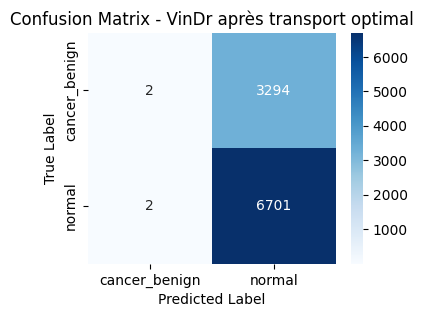

Rapport de classification :
               precision    recall  f1-score   support

cancer_benign       0.50      0.00      0.00      3296
       normal       0.67      1.00      0.80      6703

     accuracy                           0.67      9999
    macro avg       0.59      0.50      0.40      9999
 weighted avg       0.61      0.67      0.54      9999



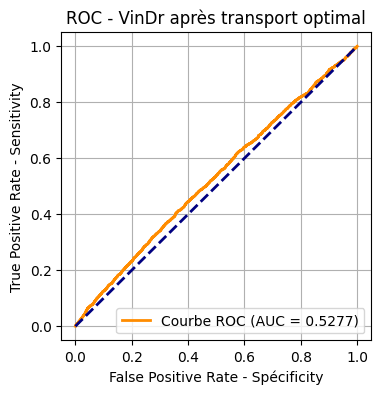

In [15]:
# Matrice de confusion
class_names = ['cancer_benign', 'normal']
cm = confusion_matrix(labels_np, predictions_np)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - VinDr après transport optimal')
plt.show()

# Rapport de classification
report = classification_report(labels_np, predictions_np, target_names=class_names)
print("Rapport de classification :")
print(report)

# Courbe ROC
fpr, tpr, thresholds = roc_curve(labels_np, probabilities_np, pos_label=0)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate - Spécificity')
plt.ylabel('True Positive Rate - Sensitivity')
plt.title('ROC - VinDr après transport optimal')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()